Epoch 1/80


c:\Users\ACER\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0058 - val_loss: 0.0554
Epoch 2/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 0.0344 - val_loss: 0.0185
Epoch 3/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.0091 - val_loss: 0.0018
Epoch 4/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0028 - val_loss: 0.0023
Epoch 5/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0033 - val_loss: 9.9245e-04
Epoch 6/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0026 - val_loss: 9.9880e-04
Epoch 7/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.0024 - val_loss: 9.4577e-04
Epoch 8/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0023 - val_loss: 0.0011
Epoch 9/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0022 - val_loss: 0.0011
Epoch 10/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0027 - val_loss: 8.4151e-04
Epoch 11/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.0022 - val_loss: 9.6105e-04
Epoch 12/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - 

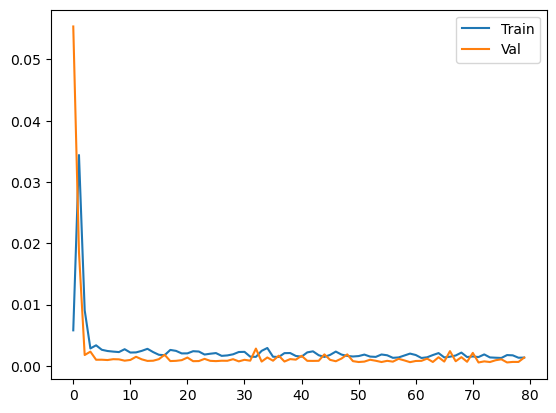

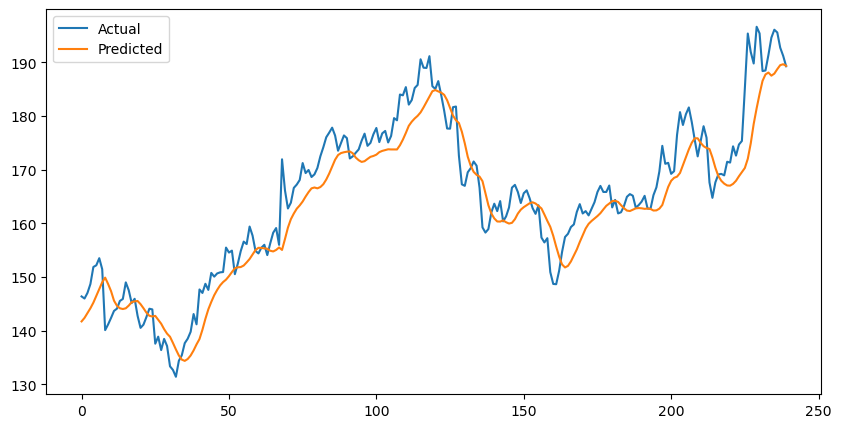

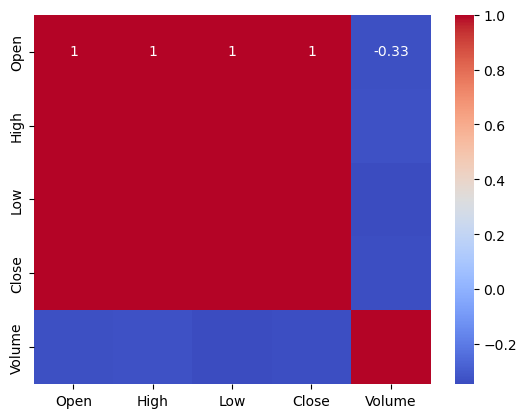

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

df = pd.read_csv("googl_data_2020_2025.csv", skiprows=[1,2])

features = ['Open','High','Low','Close','Volume']

data = MinMaxScaler().fit_transform(df[features])

X, y = [], []

for i in range(60, len(data)):
    X.append(data[i-60:i])
    y.append(data[i,3])

X, y = np.array(X), np.array(y)

x_train,x_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,shuffle=False
)

model = Sequential([
    LSTM(64,return_sequences=True,input_shape=(60,5)),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam',loss='mse')

early_stop=EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True
    )

history = model.fit(
    x_train,y_train,
    epochs=80,
    batch_size=64,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stop]
)

pred = model.predict(x_test)

scaler = MinMaxScaler()
scaler.fit(df[features])

def inverse(v):
    arr = np.zeros((len(v),5))
    arr[:,3] = v.flatten()
    return scaler.inverse_transform(arr)[:,3]

y_pred = inverse(pred)
y_actual = inverse(y_test.reshape(-1,1))

print("RMSE:",np.sqrt(mean_squared_error(y_actual,y_pred)))
print("MAE:",mean_absolute_error(y_actual,y_pred))
print("R2:",r2_score(y_actual,y_pred))

plt.plot(history.history['loss'],label='Train')
plt.plot(history.history['val_loss'],label='Val')
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(y_actual,label='Actual')
plt.plot(y_pred,label='Predicted')
plt.legend()
plt.show()

sns.heatmap(df[features].corr(),annot=True,cmap='coolwarm')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Load dataset
df = pd.read_csv("googl_data_2020_2025.csv", skiprows=[1,2])

# Input features
features = ['Open','High','Low','Close','Volume']

# -----------------------------
# Separate Scalers (Best Practice)
# -----------------------------

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

# Scale input features
X_scaled = x_scaler.fit_transform(df[features])

# Scale target column separately
y_scaled = y_scaler.fit_transform(df[['Close']])

# -----------------------------
# Create Sequences
# -----------------------------

X, y = [], []

for i in range(60, len(X_scaled)):

    # Previous 60 days
    X.append(X_scaled[i-60:i])

    # Next day Close price
    y.append(y_scaled[i])

X = np.array(X)
y = np.array(y)

# -----------------------------
# Train Test Split
# -----------------------------

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

# -----------------------------
# Build LSTM Model
# -----------------------------

model = Sequential([
    
    LSTM(
        64,
        return_sequences=True,
        input_shape=(60,5)
    ),

    Dropout(0.2),

    LSTM(64),

    Dropout(0.2),

    Dense(1)
])

# -----------------------------
# Compile Model
# -----------------------------

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# -----------------------------
# Early Stopping
# -----------------------------

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

# -----------------------------
# Train Model
# -----------------------------

history = model.fit(
    x_train,
    y_train,
    epochs=80,
    batch_size=64,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stop]
)

# -----------------------------
# Prediction
# -----------------------------

pred = model.predict(x_test)

# -----------------------------
# Inverse Transform
# -----------------------------

y_pred = y_scaler.inverse_transform(pred)

y_actual = y_scaler.inverse_transform(y_test)

# -----------------------------
# Evaluation Metrics
# -----------------------------

print("RMSE:",
      np.sqrt(mean_squared_error(y_actual, y_pred)))

print("MAE:",
      mean_absolute_error(y_actual, y_pred))

print("R2:",
      r2_score(y_actual, y_pred))

# -----------------------------
# Loss Graph
# -----------------------------

plt.plot(history.history['loss'], label='Train Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.legend()

plt.show()

# -----------------------------
# Actual vs Predicted
# -----------------------------

plt.figure(figsize=(10,5))

plt.plot(y_actual, label='Actual')

plt.plot(y_pred, label='Predicted')

plt.legend()

plt.show()

# -----------------------------
# Correlation Heatmap
# -----------------------------

sns.heatmap(
    df[features].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()